
# R01 — Pipeline C2 K-sweep (LOSO-CV) — OOM-hardened
### Overlap (STEP_SIZE=1) + run-wise normalization + multi-seed anti-collapse + explicit steps/epoch + chunked execution + auto-resume

This notebook is a drop-in replacement for the old K-sweep **and** addresses the recent **OOM-kill** by:
1) **Disabling XLA at import** (prevents accumulating compiled XLA modules that can balloon RAM over long sweeps).
2) Using **explicit `steps_per_epoch` / `validation_steps`** (removes “Unknown” dataset cardinality; reduces retracing surprises).
3) Supporting **chunked execution** (run a limited number of (fold,K) pairs per session, save, exit cleanly; then restart kernel and resume automatically).

Outputs (under `OUT_ROOT`):
- `cv_results.tsv` : one row per (fold, K) for the **selected** seed
- `cv_candidates_long.tsv` : one row per (fold, K, seed) candidate (val FE + collapse metrics)
- `fold_meta.tsv` : per-fold metadata (PCA PVE, segment counts, etc.)
- `feasibility_vs_K.png`, `mean_testFE_vs_K.png`

**Important**
- If you edit any “XLA disable” settings in Cell 0, restart kernel and run from top.
- Chunking is the *most reliable* way to avoid long-session RAM creep on WSL.


In [1]:
# =========================
# Cell 0 — USER INPUTS (edit here only)
# =========================
from pathlib import Path
import os

# -------------------------
# Dataset identity
# -------------------------
DATA_VARIANT = "intermediate"
FEATURE_MODE = "nolags"   # "lags" or "nolags"
MINLEN       = 15

# K sweep grid
K_GRID = list(range(2, 13))

# -------------------------
# Paths (WSL format)
# -------------------------
FINAL_ROOT = Path("/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/align_trmask_lags/FINAL_v3_gnorm_allTR") / DATA_VARIANT

# If you prefer to hardcode the manifest, set MANIFEST_TSV explicitly.
# Otherwise, leave as None and it will auto-find it under FINAL_ROOT.
MANIFEST_TSV = None  # e.g., FINAL_ROOT / "hmm_segments_minlen15_nolags" / "segments_manifest.tsv"

# Output root
OUT_ROOT = Path("/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_LOSO_Ksweep_C2") / f"{DATA_VARIANT}_{FEATURE_MODE}_minlen{MINLEN}"

# -------------------------
# Feature layout (Pipeline B builds X = [BOLD | EEG])
# -------------------------
N_PARCELS = 200
TR_SEC    = 2.1

if FEATURE_MODE.lower() == "lags":
    LAGS_TR = [-1, 0, 1]
elif FEATURE_MODE.lower() == "nolags":
    LAGS_TR = [0]
else:
    raise ValueError("FEATURE_MODE must be 'lags' or 'nolags'")

D_BOLD  = N_PARCELS
D_EEG   = N_PARCELS * len(LAGS_TR)
D_TOTAL = D_BOLD + D_EEG

# -------------------------
# Windowing (C2 paradigm)
# -------------------------
SEQ_LEN    = 10
STEP_SIZE  = 1       # overlap within each segment (NO stitching across segments)
BATCH_SIZE = 16

# When concatenating per-segment datasets, shuffle happens at the batch level.
SHUFFLE_BUFFER = 2048  # batches

REBATCH_DROP_REMAINDER = True   # avoids variable batch shapes at segment boundaries (prevents repeated XLA recompiles)

# -------------------------
# Fold-wise PCA (leakage-safe; fit on training-only)
# -------------------------
N_BOLD_PCS = 40
N_EEG_PCS  = 40

# -------------------------
# Training hyperparameters (starting point)
# -------------------------
LEARNING_RATE = 1e-3
N_EPOCHS_CV   = 60

CV_LEARN_MEANS   = True
CV_LEARN_COVS    = True
CV_LEARN_TRANS   = True
CV_DIAGONAL_COVS = False   # recommended FULL covariances for C2
COV_EPS          = 1e-6

# Initialization per seed
INIT_TAKE      = 0.30
INIT_EPOCHS    = 5
BIGK_THRESH    = 6
INIT_TAKE_BIGK = 0.20

# Multi-seed restarts (anti-collapse)
SEEDS = [11, 23, 37, 53, 71]

# Inner validation policy (within training subjects)
VAL_SUBJECT_POLICY = "max_segments"

# Run-wise normalization (key anti-collapse lever)
USE_RUNWISE_ZSCORE = True

# Collapse screening thresholds (on validation)
FO_MAX_THRESH     = 0.95
ENTROPY_NORM_MIN  = 0.05
FO_ACTIVE_THRESH  = 0.01
MIN_ACTIVE_STATES_BASE = 3  # capped at K

# -------------------------
# OOM hardening
# -------------------------
# Disable XLA at import (MUST be set before tensorflow is imported in Cell 1)
DISABLE_XLA_AT_IMPORT = True
if DISABLE_XLA_AT_IMPORT:
    os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=-1"  # hard-off for auto-clustering
    os.environ["TF_XLA_ENABLE_XLA_DEVICES"] = "0"
    os.environ["XLA_FLAGS"] = ""  # clear any inherited XLA flags

# Keep eager OFF for long sweeps (eager tends to be slower and can increase RAM overhead)
FORCE_EAGER = False

# Reduce tf.data aggressiveness (safer under WSL + long loops)
DISABLE_PREFETCH  = True
DISABLE_CALLBACKS = True

# GPU memory cap (your laptop GPU)
GPU_MEMORY_LIMIT_MB = 4096  # set None to use memory_growth

# -------------------------
# Chunked execution + auto-resume (recommended)
# -------------------------
RESUME_IF_RESULTS_EXIST = True

# Process at most this many NEW (fold,K) pairs, then save and stop cleanly.
# After it stops: restart kernel and run Cell 4 again to continue.
MAX_NEW_PAIRS_PER_RUN = 15   # e.g., 10–25

# Optional subset controls (leave as None for full sweep)
DEBUG_MAX_FOLDS = None     # e.g., 1
DEBUG_K_GRID    = None     # e.g., [2,3,4]
DEBUG_SEEDS     = None     # e.g., [11]

print("FINAL_ROOT:", FINAL_ROOT)
print("MANIFEST_TSV:", MANIFEST_TSV)
print("OUT_ROOT:", OUT_ROOT)
print(f"D_TOTAL={D_TOTAL} (BOLD={D_BOLD}, EEG={D_EEG})")
print("K_GRID:", K_GRID)
print("SEQ_LEN:", SEQ_LEN, "STEP_SIZE:", STEP_SIZE, "BATCH_SIZE:", BATCH_SIZE)
print("SEEDS:", SEEDS)
print("MAX_NEW_PAIRS_PER_RUN:", MAX_NEW_PAIRS_PER_RUN)


FINAL_ROOT: /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/align_trmask_lags/FINAL_v3_gnorm_allTR/intermediate
MANIFEST_TSV: None
OUT_ROOT: /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_LOSO_Ksweep_C2/intermediate_nolags_minlen15
D_TOTAL=400 (BOLD=200, EEG=200)
K_GRID: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
SEQ_LEN: 10 STEP_SIZE: 1 BATCH_SIZE: 16
SEEDS: [11, 23, 37, 53, 71]
MAX_NEW_PAIRS_PER_RUN: 15


In [2]:
# =========================
# Cell 1 — Imports + manifest resolution + load segment paths
# =========================
import os, gc
from pathlib import Path

import numpy as np
import pandas as pd

# IMPORTANT: if you changed DISABLE_XLA_AT_IMPORT in Cell 0, restart kernel before running this cell.

import tensorflow as tf
from osl_dynamics.data import Data
from osl_dynamics.models.hmm import Config, Model

OUT_ROOT.mkdir(parents=True, exist_ok=True)
CV_TSV       = OUT_ROOT / "cv_results.tsv"
CAND_TSV     = OUT_ROOT / "cv_candidates_long.tsv"
FOLD_META_TSV= OUT_ROOT / "fold_meta.tsv"

def auto_find_manifest(final_root: Path, feature_mode: str, minlen: int) -> Path:
    mode = feature_mode.lower()
    candidates = [
        final_root / f"hmm_segments_minlen{minlen}_{mode}" / "segments_manifest.tsv",
        final_root / f"hmm_segments_minlen{minlen}" / "segments_manifest.tsv",
    ]
    for m in candidates:
        if m.exists():
            return m
    hits = list(final_root.rglob("segments_manifest.tsv"))
    if hits:
        def score(p: Path):
            s = str(p)
            sc = 0
            if f"minlen{minlen}" in s: sc += 10
            if mode in s: sc += 5
            return sc
        hits = sorted(hits, key=score, reverse=True)
        return hits[0]
    raise FileNotFoundError(f"Could not find segments_manifest.tsv under {final_root}")

if MANIFEST_TSV is None:
    MANIFEST_TSV = auto_find_manifest(FINAL_ROOT, FEATURE_MODE, MINLEN)

print("MANIFEST_TSV:", MANIFEST_TSV)
manifest = pd.read_csv(MANIFEST_TSV, sep="\t")
print("Rows:", len(manifest))
print("Columns:", list(manifest.columns))
display(manifest.head())

if "run" not in manifest.columns or "seg_path" not in manifest.columns:
    raise ValueError("Expected manifest columns: 'run', 'seg_path'. Please confirm header.")

def parse_subject(run: str) -> str:
    parts = str(run).split("_")
    for p in parts:
        if p.startswith("sub-"):
            return p
    return parts[0]

manifest["subject"] = manifest["run"].apply(parse_subject)
sort_cols = ["subject", "run"]
if "seg_id" in manifest.columns:
    sort_cols.append("seg_id")
manifest = manifest.sort_values(sort_cols).reset_index(drop=True)

SEG_ROOT = MANIFEST_TSV.parent
def resolve_seg_path(p: str) -> Path:
    pp = Path(p)
    return pp if pp.is_absolute() else (SEG_ROOT / pp)

seg_paths = [resolve_seg_path(p) for p in manifest["seg_path"].tolist()]
missing = [p for p in seg_paths if not p.exists()]
if missing:
    print("Missing seg files (first 10):", missing[:10])
    raise FileNotFoundError("Some segment files do not exist.")

# We keep raw segments in memory for speed (usually modest); TF/XLA was your real RAM driver.
all_X = [np.load(p).astype(np.float32) for p in seg_paths]
manifest["X_index"] = np.arange(len(manifest), dtype=int)

x0 = all_X[0]
print("Example segment shape:", x0.shape)
assert x0.shape[1] == D_TOTAL, f"Expected D={D_TOTAL}, got {x0.shape[1]}"
print(f"Loaded {len(all_X)} segments | total TR = {int(np.sum([x.shape[0] for x in all_X]))}")


2026-02-24 18:42:02.368603: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-24 18:42:03.176870: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771929723.484687  408332 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771929723.606794  408332 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771929724.046317  408332 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

MANIFEST_TSV: /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/align_trmask_lags/FINAL_v3_gnorm_allTR/intermediate/hmm_segments_minlen15_nolags/segments_manifest.tsv
Rows: 71
Columns: ['run', 'feature_mode', 'lags_tr', 'seg_id', 'start_TR', 'end_TR', 'len_TR', 'start_sec', 'end_sec', 'dur_sec', 'n_features', 'seg_path']


,run,feature_mode,lags_tr,seg_id,start_TR,end_TR,len_TR,start_sec,end_sec,dur_sec,n_features,seg_path
0,sub-01_ses-01,nolags,0,sub-01_ses-01__seg0000,1,21,20,2.1,44.1,42.0,400,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...
1,sub-01_ses-01,nolags,0,sub-01_ses-01__seg0001,22,42,20,46.2,88.2,42.0,400,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...
2,sub-01_ses-01,nolags,0,sub-01_ses-01__seg0002,43,83,40,90.3,174.3,84.0,400,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...
3,sub-01_ses-01,nolags,0,sub-01_ses-01__seg0003,84,159,75,176.4,333.9,157.5,400,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...
4,sub-01_ses-01,nolags,0,sub-01_ses-01__seg0004,160,259,99,336.0,543.9,207.9,400,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...


Example segment shape: (20, 400)
Loaded 71 segments | total TR = 3550


In [3]:
# =========================
# Cell 2 — TensorFlow GPU config (cap 4GB) + disable JIT
# =========================
# Optional: reduce thread parallelism (often stabilizes long runs under WSL)
try:
    tf.config.threading.set_intra_op_parallelism_threads(1)
    tf.config.threading.set_inter_op_parallelism_threads(1)
except Exception:
    pass

gpus = tf.config.list_physical_devices("GPU")
print("GPUs visible to TF:", gpus)

if gpus:
    try:
        if GPU_MEMORY_LIMIT_MB is not None:
            tf.config.set_logical_device_configuration(
                gpus[0],
                [tf.config.LogicalDeviceConfiguration(memory_limit=int(GPU_MEMORY_LIMIT_MB))]
            )
            print(f"[INFO] Capped GPU memory to {int(GPU_MEMORY_LIMIT_MB)} MB.")
        else:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            print("[INFO] Enabled memory_growth (no explicit cap).")
    except Exception as e:
        print("[WARN] GPU config:", e)
else:
    print("[INFO] Running CPU-only.")

# Disable TF JIT (not sufficient alone, but still useful)
try:
    tf.config.optimizer.set_jit(False)
    print("[INFO] tf.config.optimizer.set_jit(False)")
except Exception as e:
    print("[WARN] set_jit:", e)

if FORCE_EAGER:
    tf.config.run_functions_eagerly(True)
    print("[INFO] FORCE_EAGER=True")
else:
    print("[INFO] FORCE_EAGER=False (recommended for memory efficiency)")

# quick sanity
a = tf.random.normal((64, 64))
_ = tf.matmul(a, a)
print("TF OK")


GPUs visible to TF: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[INFO] Capped GPU memory to 4096 MB.
[INFO] tf.config.optimizer.set_jit(False)
[INFO] FORCE_EAGER=False (recommended for memory efficiency)


I0000 00:00:1771929738.103357  408332 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4096 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


TF OK


In [4]:
# =========================
# Cell 3 — Helpers (run-wise zscore, leakage-safe PCA, merged dataset, explicit steps/epoch, collapse metrics)
# =========================
import math

def gc_now():
    gc.collect()

def count_windows_for_segments(X_list):
    # number of sliding windows per segment (no cross-segment windows)
    n = 0
    for x in X_list:
        T = int(x.shape[0])
        if T >= SEQ_LEN:
            n += 1 + (T - SEQ_LEN) // STEP_SIZE
    return int(n)

def steps_from_windows(n_windows: int):
    """Compute steps_per_epoch given number of windows.

    If we rebatch with drop_remainder=True, steps is floor(n_windows / BATCH_SIZE).
    Otherwise it's ceil(...).
    """
    if n_windows <= 0:
        return 0
    if REBATCH_DROP_REMAINDER:
        return int(n_windows // int(BATCH_SIZE))
    return int(math.ceil(n_windows / float(BATCH_SIZE)))


def runwise_zscore_segments(X_list, run_ids, sl: slice):
    run_ids = np.asarray(run_ids, dtype=object)
    uniq = pd.unique(run_ids)
    mu, sd = {}, {}
    for r in uniq:
        idx = np.where(run_ids == r)[0]
        X = np.concatenate([X_list[i][:, sl] for i in idx], axis=0)
        m = X.mean(axis=0)
        s = X.std(axis=0, ddof=0)
        s[s < 1e-12] = 1.0
        mu[r] = m
        sd[r] = s
    out = []
    for X, r in zip(X_list, run_ids):
        Z = X.copy()
        Z[:, sl] = (Z[:, sl] - mu[r]) / sd[r]
        out.append(Z.astype(np.float32))
    return out

def fit_standardizer(X):
    mu = X.mean(axis=0)
    sd = X.std(axis=0, ddof=0)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return mu.astype(np.float32), sd.astype(np.float32)

def apply_standardizer(X, mu, sd):
    return ((X - mu) / sd).astype(np.float32)

def fit_pca(X, n_fixed):
    mu = X.mean(axis=0, keepdims=True)
    Xc = X - mu
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    n_comp = int(min(n_fixed, Vt.shape[0]))
    V = Vt[:n_comp].T.astype(np.float32)
    var = (S**2) / max(Xc.shape[0] - 1, 1)
    pve = float(np.sum(var[:n_comp]) / np.sum(var)) if np.sum(var) > 0 else np.nan
    return mu.ravel().astype(np.float32), V, pve

def apply_pca(X, mu, V):
    return ((X - mu) @ V).astype(np.float32)

def make_fold_preproc(X_tr_raw_list):
    Xtr = np.concatenate(X_tr_raw_list, axis=0)
    Xb, Xe = Xtr[:, :D_BOLD], Xtr[:, D_BOLD:]

    mu_b, sd_b = fit_standardizer(Xb)
    mu_e, sd_e = fit_standardizer(Xe)

    Xb_z = apply_standardizer(Xb, mu_b, sd_b)
    Xe_z = apply_standardizer(Xe, mu_e, sd_e)

    mu_pb, Vb, pve_b = fit_pca(Xb_z, N_BOLD_PCS)
    mu_pe, Ve, pve_e = fit_pca(Xe_z, N_EEG_PCS)

    params = dict(mu_b=mu_b, sd_b=sd_b, mu_e=mu_e, sd_e=sd_e,
                  mu_pb=mu_pb, Vb=Vb, mu_pe=mu_pe, Ve=Ve)
    meta = dict(pve_bold=pve_b, pve_eeg=pve_e,
                n_bold_pcs=int(Vb.shape[1]), n_eeg_pcs=int(Ve.shape[1]),
                D_pca=int(Vb.shape[1] + Ve.shape[1]))
    return params, meta

def apply_fold_preproc(X, params):
    Xb = apply_standardizer(X[:, :D_BOLD], params["mu_b"], params["sd_b"])
    Xe = apply_standardizer(X[:, D_BOLD:], params["mu_e"], params["sd_e"])
    Xb_p = apply_pca(Xb, params["mu_pb"], params["Vb"])
    Xe_p = apply_pca(Xe, params["mu_pe"], params["Ve"])
    return np.concatenate([Xb_p, Xe_p], axis=1).astype(np.float32)

def choose_val_subject(train_df):
    if VAL_SUBJECT_POLICY == "max_segments":
        return train_df.groupby("subject").size().sort_values(ascending=False).index[0]
    return sorted(train_df["subject"].unique().tolist())[0]

def make_config(K, D):
    cfg = Config(
        n_states=K,
        n_channels=D,
        sequence_length=SEQ_LEN,
        learn_means=CV_LEARN_MEANS,
        learn_covariances=CV_LEARN_COVS,
        learn_trans_prob=CV_LEARN_TRANS,
        batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        n_epochs=N_EPOCHS_CV,
        covariances_epsilon=COV_EPS,
    )
    try:
        cfg.covariance_matrix_type = "diag" if CV_DIAGONAL_COVS else "full"
    except Exception:
        pass
    # IMPORTANT: one init per seed (we do multi-seed restarts)
    try:
        cfg.n_init = 1
    except Exception:
        pass
    return cfg

def callbacks():
    if DISABLE_CALLBACKS:
        return []
    cbs = []
    # You can re-enable these later if stable.
    return cbs

def as_tf_dataset(data: Data, shuffle: bool):
    # In osl-dynamics 2.1.5, concatenate=False may return a list of datasets (one per segment).
    ds_obj = data.dataset(
        sequence_length=SEQ_LEN,
        step_size=STEP_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
        concatenate=False,
    )

    if isinstance(ds_obj, (list, tuple)):
        ds_list = list(ds_obj)
        if len(ds_list) == 0:
            raise ValueError("Data.dataset returned empty list (no windows). Check SEQ_LEN/STEP_SIZE vs segment lengths.")
        ds = ds_list[0]
        for d in ds_list[1:]:
            ds = ds.concatenate(d)
    else:
        ds = ds_obj

    # Key stability fix:
    # Per-segment datasets may end with smaller final batches -> variable batch shapes at boundaries
    # -> TF retracing/XLA recompiles -> big compile time + RAM growth.
    if REBATCH_DROP_REMAINDER:
        try:
            ds = ds.unbatch().batch(int(BATCH_SIZE), drop_remainder=True)
        except Exception:
            pass

    if shuffle:
        try:
            ds = ds.shuffle(buffer_size=int(SHUFFLE_BUFFER), reshuffle_each_iteration=True)
        except Exception:
            pass

    if not DISABLE_PREFETCH:
        try:
            ds = ds.prefetch(tf.data.AUTOTUNE)
        except Exception:
            pass
    return ds

def free_energy(model, data: Data):
    ds = as_tf_dataset(data, shuffle=False)
    fe = model.free_energy(ds)
    if isinstance(fe, (list, tuple, np.ndarray)):
        fe = float(np.asarray(fe).ravel()[0])
    return float(fe)

def normalize_alpha_list(alpha_like):
    if isinstance(alpha_like, (list, tuple)):
        out = []
        for a in alpha_like:
            a = np.asarray(a)
            if a.ndim == 2:
                out.append(a)
            elif a.ndim == 3:
                out.extend([a[i] for i in range(a.shape[0])])
            else:
                raise ValueError(f"Unexpected alpha element ndim={a.ndim}, shape={a.shape}")
        return out
    a = np.asarray(alpha_like)
    if a.ndim == 2:
        return [a]
    if a.ndim == 3:
        return [a[i] for i in range(a.shape[0])]
    raise ValueError(f"Unexpected alpha ndim={a.ndim}, shape={a.shape}")

def get_alpha_list(model, data: Data):
    if hasattr(model, "get_alpha"):
        out = model.get_alpha(data, concatenate=False, verbose=0)
        return normalize_alpha_list(out)
    if hasattr(model, "get_gamma"):
        out = model.get_gamma(data, concatenate=False, verbose=0)
        return normalize_alpha_list(out)
    raise AttributeError("Model does not expose get_alpha/get_gamma.")

def summarize_alpha(alpha_list, K, eps=1e-12):
    alpha_list = normalize_alpha_list(alpha_list)
    tot_T = 0
    fo_num = np.zeros(K, dtype=np.float64)
    ent_sum_norm = 0.0
    for a in alpha_list:
        a = np.asarray(a, dtype=np.float64)
        if a.ndim != 2 or a.shape[1] != K:
            raise ValueError(f"Expected alpha shape (T,{K}); got {a.shape}")
        tot_T += a.shape[0]
        fo_num += a.sum(axis=0)
        a_clip = np.clip(a, eps, 1.0)
        Ht = -(a_clip * np.log(a_clip)).sum(axis=1)
        ent_sum_norm += (Ht / np.log(K)).sum()
    fo = (fo_num / max(tot_T, 1))
    fo_max = float(np.max(fo)) if fo.size else np.nan
    ent_norm = float(ent_sum_norm / max(tot_T, 1))
    n_active = int(np.sum(fo > FO_ACTIVE_THRESH)) if fo.size else 0
    return fo.astype(np.float32), fo_max, ent_norm, n_active

def fo_entropy_and_neff(fo, K, eps=1e-12):
    """
    Global occupancy diversity metrics computed from FO (fractional occupancy).

    fo_entropy_norm: FO-entropy normalized to [0,1] by log(K).
        - 0 means all mass on one state
        - 1 means perfectly uniform over states
    neff: "effective number of states" = exp(H(FO)) in [1, K]
    """
    fo = np.asarray(fo, dtype=np.float64)
    if fo.ndim != 1 or fo.size != K:
        raise ValueError(f"Expected fo shape ({K},), got {fo.shape}")
    fo = np.clip(fo, eps, 1.0)
    fo = fo / fo.sum()

    H_nat = float(-(fo * np.log(fo)).sum())         # natural entropy
    fo_entropy_norm = float(H_nat / np.log(K))      # normalized
    neff = float(np.exp(H_nat))                     # effective #states
    return fo_entropy_norm, neff


def is_collapsed(fo_max, n_active, K):
    """
    Anti-collapse screen (feasibility):
    - do NOT use timepoint gamma entropy; it's mainly a "confidence" measure.
    - collapse means "globally degenerate" usage of states.
    """
    min_active = min(int(MIN_ACTIVE_STATES_BASE), int(K))

    if not np.isfinite(fo_max):
        return True
    if fo_max > FO_MAX_THRESH:
        return True
    if int(n_active) < int(min_active):
        return True
    return False


def choose_best_candidate(cands):
    """
    Select best seed among candidates.
    Preference order:
      1) non-collapsed candidates first (if any exist)
      2) lowest val free energy
      3) lower fo_max (less dominance)
      4) higher n_active
      5) higher FO-entropy (more globally diverse occupancy)
    """
    non = [c for c in cands if not c["collapsed"]]
    pool = non if len(non) else cands

    def key(c):
        fe = c.get("fe_val", np.nan)
        fe = fe if np.isfinite(fe) else np.inf

        fm = c.get("fo_max", np.nan)
        fm = fm if np.isfinite(fm) else np.inf

        na = int(c.get("n_active", 0))

        fhe = c.get("fo_entropy", np.nan)
        fhe = fhe if np.isfinite(fhe) else -np.inf

        return (fe, fm, -na, -fhe)

    return sorted(pool, key=key)[0]
    
def clear_session():
    # Keep minimal teardown; full clear_session can be unstable on some setups.
    try:
        tf.keras.backend.clear_session()
    except Exception:
        pass
    gc_now()


In [5]:
# =========================
# Cell 4 — LOSO-CV K-sweep (multi-seed anti-collapse) with explicit steps/epoch + chunked execution + resume
# =========================
def split_loso(df: pd.DataFrame):
    subs = sorted(df["subject"].unique().tolist())
    for fi, test_sub in enumerate(subs):
        train_idx = df.index[df["subject"] != test_sub].to_numpy()
        test_idx  = df.index[df["subject"] == test_sub].to_numpy()
        yield fi, test_sub, train_idx, test_idx

# Apply optional subset controls
K_GRID_RUN = DEBUG_K_GRID if DEBUG_K_GRID is not None else K_GRID
SEEDS_RUN  = DEBUG_SEEDS if DEBUG_SEEDS is not None else SEEDS

done = set()
if RESUME_IF_RESULTS_EXIST and CV_TSV.exists():
    prev = pd.read_csv(CV_TSV, sep="\t")
    for _, r in prev.iterrows():
        done.add((int(r["fold"]), int(r["K"])))
    print(f"[RESUME] existing rows={len(prev)} | done pairs={len(done)}")
else:
    print("[START] no previous results (or resume off)")

# We'll append to in-memory lists but also save incrementally
cv_rows = []
cand_rows = []
if RESUME_IF_RESULTS_EXIST and CV_TSV.exists():
    cv_rows = pd.read_csv(CV_TSV, sep="\t").to_dict("records")
if RESUME_IF_RESULTS_EXIST and CAND_TSV.exists():
    cand_rows = pd.read_csv(CAND_TSV, sep="\t").to_dict("records")

fold_meta = []
new_pairs_done = 0

for fold_i, test_sub, train_idx, test_idx in split_loso(manifest):
    if DEBUG_MAX_FOLDS is not None and fold_i >= int(DEBUG_MAX_FOLDS):
        print(f"[DEBUG] stopping after fold {fold_i}")
        break

    print(f"===== Fold {fold_i+1}/{manifest['subject'].nunique()} | test subject = {test_sub} =====")

    train_df = manifest.loc[train_idx].copy()
    test_df  = manifest.loc[test_idx].copy()

    val_sub = choose_val_subject(train_df)
    val_df = train_df.loc[train_df["subject"] == val_sub].copy()
    trn_df = train_df.loc[train_df["subject"] != val_sub].copy()

    # Raw segments
    X_trn_raw = [all_X[i] for i in trn_df["X_index"].tolist()]
    X_val_raw = [all_X[i] for i in val_df["X_index"].tolist()]
    X_tst_raw = [all_X[i] for i in test_df["X_index"].tolist()]

    trn_runs = trn_df["run"].tolist()
    val_runs = val_df["run"].tolist()
    tst_runs = test_df["run"].tolist()

    if USE_RUNWISE_ZSCORE:
        X_trn_raw = runwise_zscore_segments(X_trn_raw, trn_runs, slice(0, D_BOLD))
        X_trn_raw = runwise_zscore_segments(X_trn_raw, trn_runs, slice(D_BOLD, D_TOTAL))
        X_val_raw = runwise_zscore_segments(X_val_raw, val_runs, slice(0, D_BOLD))
        X_val_raw = runwise_zscore_segments(X_val_raw, val_runs, slice(D_BOLD, D_TOTAL))
        X_tst_raw = runwise_zscore_segments(X_tst_raw, tst_runs, slice(0, D_BOLD))
        X_tst_raw = runwise_zscore_segments(X_tst_raw, tst_runs, slice(D_BOLD, D_TOTAL))

    # Train-only PCA
    params, meta = make_fold_preproc(X_trn_raw)
    print(f"  PCA PVE(train): BOLD {100*meta['pve_bold']:.1f}% ({meta['n_bold_pcs']} PCs) | EEG {100*meta['pve_eeg']:.1f}% ({meta['n_eeg_pcs']} PCs)")
    print(f"  Fold D_pca={meta['D_pca']} | train segs={len(X_trn_raw)} | val segs={len(X_val_raw)} | test segs={len(X_tst_raw)}")

    X_trn = [apply_fold_preproc(X, params) for X in X_trn_raw]
    X_val = [apply_fold_preproc(X, params) for X in X_val_raw]
    X_tst = [apply_fold_preproc(X, params) for X in X_tst_raw]

    # Window counts -> explicit steps
    nwin_tr = count_windows_for_segments(X_trn)
    nwin_va = count_windows_for_segments(X_val)
    steps_tr = steps_from_windows(nwin_tr)
    steps_va = steps_from_windows(nwin_va)
    # FALLBACK: if drop_remainder rebatching makes steps==0 (very small split), disable rebatching for this fold.
    if steps_tr == 0 or steps_va == 0:
        if REBATCH_DROP_REMAINDER:
            print("[WARN] steps==0 under drop_remainder rebatching; disabling rebatch for this fold.")
            globals()["REBATCH_DROP_REMAINDER"] = False
            steps_tr = steps_from_windows(nwin_tr)
            steps_va = steps_from_windows(nwin_va)
    if steps_tr == 0 or steps_va == 0:
        raise RuntimeError(f"Zero steps in fold {fold_i}. Check SEQ_LEN/STEP_SIZE and segment lengths.")

    train_data = Data(X_trn)
    val_data   = Data(X_val)
    test_data  = Data(X_tst)

    fold_meta.append(dict(
        fold=fold_i, test_subject=test_sub, val_subject=val_sub,
        D_pca=meta["D_pca"], pve_bold=meta["pve_bold"], pve_eeg=meta["pve_eeg"],
        n_bold_pcs=meta["n_bold_pcs"], n_eeg_pcs=meta["n_eeg_pcs"],
        n_train_segments=len(X_trn), n_val_segments=len(X_val), n_test_segments=len(X_tst),
        nwin_train=int(nwin_tr), nwin_val=int(nwin_va),
        steps_per_epoch=int(steps_tr), validation_steps=int(steps_va),
        seq_len=int(SEQ_LEN), step_size=int(STEP_SIZE), batch_size=int(BATCH_SIZE),
        runwise_zscore=bool(USE_RUNWISE_ZSCORE)
    ))

    for K in K_GRID_RUN:
        if (fold_i, K) in done:
            continue

        cfg = make_config(K, meta["D_pca"])
        init_take = INIT_TAKE_BIGK if K >= BIGK_THRESH else INIT_TAKE

        print(f"  [K={K}] steps_per_epoch={steps_tr} | val_steps={steps_va} | seeds={SEEDS_RUN}")
        candidates = []

        # Candidate pass: evaluate each seed on val FE + collapse metrics
        for seed in SEEDS_RUN:
            print(f"    seed={seed} …", end=" ")
            clear_session()
            np.random.seed(int(seed))
            tf.random.set_seed(int(seed))

            train_ds = as_tf_dataset(train_data, shuffle=True)
            val_ds   = as_tf_dataset(val_data, shuffle=False)

            m = Model(cfg)
            try:
                # keep single init per seed (if supported)
                try:
                    m.random_subset_initialization(train_data, take=float(init_take), n_epochs=int(INIT_EPOCHS), n_init=1)
                except TypeError:
                    m.random_subset_initialization(train_data, take=float(init_take), n_epochs=int(INIT_EPOCHS))
            except Exception as e:
                print("INIT_FAIL")
                continue

            try:
                m.fit(
                    train_ds,
                    validation_data=val_ds,
                    steps_per_epoch=int(steps_tr),
                    validation_steps=int(steps_va),
                    callbacks=callbacks()
                )
            except TypeError:
                # some versions don't accept callbacks
                m.fit(
                    train_ds,
                    validation_data=val_ds,
                    steps_per_epoch=int(steps_tr),
                    validation_steps=int(steps_va),
                )
            except Exception as e:
                print("FIT_FAIL")
                continue

            try:
                fe_val = free_energy(m, val_data)
            except Exception:
                fe_val = np.nan

            try:
                alpha_val = get_alpha_list(m, val_data)

                # timepoint summary (kept for reporting)
                fo, fo_max, ent_norm, n_active = summarize_alpha(alpha_val, K)

                # global FO diversity (better for “collapse” meaning)
                fo_entropy, neff = fo_entropy_and_neff(fo, K)

                # collapse screen = global degeneracy only
                collapsed = is_collapsed(fo_max, n_active, K)
            except Exception:
                fo_max, ent_norm, n_active, collapsed = np.nan, np.nan, 0, True

            cand = dict(
                fold=fold_i, test_subject=test_sub, val_subject=val_sub,
                K=int(K), seed=int(seed), init_take=float(init_take),
                fe_val=float(fe_val) if np.isfinite(fe_val) else np.nan,
                fo_max=float(fo_max) if np.isfinite(fo_max) else np.nan,
                entropy_norm=float(ent_norm) if np.isfinite(ent_norm) else np.nan,  # kept for description
                n_active=int(n_active),
                fo_entropy=float(fo_entropy) if np.isfinite(fo_entropy) else np.nan,
                neff=float(neff) if np.isfinite(neff) else np.nan,
                collapsed=bool(collapsed),
            )
            candidates.append(cand)
            cand_rows.append(cand)
            print(f"FE_val={cand['fe_val']:.3f} | collapsed={cand['collapsed']}")

            # cleanup per seed
            try:
                del m, train_ds, val_ds, alpha_val
            except Exception:
                pass
            gc_now()

        if len(candidates) == 0:
            # record empty
            row = dict(fold=fold_i, test_subject=test_sub, val_subject=val_sub, K=int(K),
                       seed_selected=np.nan, collapsed=True,
                       fe_train=np.nan, fe_val=np.nan, fe_test=np.nan,
                       fo_max=np.nan, entropy_norm=np.nan, n_active=0,
                       n_seeds_tried=0, init_take=float(init_take),
                       D_pca=int(meta["D_pca"]),
                       feature_mode=FEATURE_MODE.lower(),
                       seq_len=int(SEQ_LEN), step_size=int(STEP_SIZE), batch_size=int(BATCH_SIZE),
                       runwise_zscore=bool(USE_RUNWISE_ZSCORE))
            cv_rows.append(row)
            done.add((fold_i, K))
        else:
            best = choose_best_candidate(candidates)
            print(f"    BEST seed={best['seed']} | collapsed={best['collapsed']} | FE_val={best['fe_val']:.3f} | FOmax={best['fo_max']:.3f} | Hnorm={best['entropy_norm']:.3f} | n_active={best['n_active']}")

            # Refit best seed once to compute train/test FE
            clear_session()
            np.random.seed(int(best["seed"]))
            tf.random.set_seed(int(best["seed"]))

            train_ds = as_tf_dataset(train_data, shuffle=True)
            val_ds   = as_tf_dataset(val_data, shuffle=False)

            m = Model(cfg)
            try:
                try:
                    m.random_subset_initialization(train_data, take=float(init_take), n_epochs=int(INIT_EPOCHS), n_init=1)
                except TypeError:
                    m.random_subset_initialization(train_data, take=float(init_take), n_epochs=int(INIT_EPOCHS))
                try:
                    m.fit(train_ds, validation_data=val_ds, steps_per_epoch=int(steps_tr), validation_steps=int(steps_va), callbacks=callbacks())
                except TypeError:
                    m.fit(train_ds, validation_data=val_ds, steps_per_epoch=int(steps_tr), validation_steps=int(steps_va))
                fe_tr = free_energy(m, train_data)
                fe_te = free_energy(m, test_data)
            except Exception as e:
                print("    [WARN] refit(best) failed:", repr(e))
                fe_tr = fe_te = np.nan

            row = dict(
                fold=fold_i, test_subject=test_sub, val_subject=val_sub, K=int(K),
                seed_selected=int(best["seed"]),
                collapsed=bool(best["collapsed"]),
                fe_train=float(fe_tr) if np.isfinite(fe_tr) else np.nan,
                fe_val=float(best["fe_val"]) if np.isfinite(best["fe_val"]) else np.nan,
                fe_test=float(fe_te) if np.isfinite(fe_te) else np.nan,
                fo_max=float(best["fo_max"]),
                entropy_norm=float(best["entropy_norm"]),
                fo_entropy=float(fo_entropy) if np.isfinite(fo_entropy) else np.nan,
                neff=float(neff) if np.isfinite(neff) else np.nan,
                n_active=int(best["n_active"]),
                n_seeds_tried=int(len(candidates)),
                init_take=float(init_take),
                D_pca=int(meta["D_pca"]),
                feature_mode=FEATURE_MODE.lower(),
                seq_len=int(SEQ_LEN), step_size=int(STEP_SIZE), batch_size=int(BATCH_SIZE),
                runwise_zscore=bool(USE_RUNWISE_ZSCORE),
            )
            cv_rows.append(row)
            done.add((fold_i, K))

            # cleanup
            try:
                del m, train_ds, val_ds
            except Exception:
                pass
            gc_now()

        # Incremental saves (resume-safe)
        pd.DataFrame(cv_rows).to_csv(CV_TSV, sep="\t", index=False)
        pd.DataFrame(cand_rows).to_csv(CAND_TSV, sep="\t", index=False)
        pd.DataFrame(fold_meta).to_csv(FOLD_META_TSV, sep="\t", index=False)

        new_pairs_done += 1
        if MAX_NEW_PAIRS_PER_RUN is not None and new_pairs_done >= int(MAX_NEW_PAIRS_PER_RUN):
            print(f"[CHUNK DONE] processed {new_pairs_done} new (fold,K) pairs. Saved and stopping to avoid OOM.")
            raise SystemExit("Chunk complete. Restart kernel and run Cell 4 again to resume.")

print("Finished full sweep.")


[RESUME] existing rows=131 | done pairs=131
===== Fold 1/12 | test subject = sub-01 =====
  PCA PVE(train): BOLD 66.9% (40 PCs) | EEG 92.3% (40 PCs)
  Fold D_pca=80 | train segs=55 | val segs=10 | test segs=6


Loading files:   0%|          | 0/55 [00:00<?, ?it/s]

Loading files:   0%|          | 0/10 [00:00<?, ?it/s]

Loading files:   0%|          | 0/6 [00:00<?, ?it/s]

===== Fold 2/12 | test subject = sub-02 =====
  PCA PVE(train): BOLD 67.3% (40 PCs) | EEG 92.1% (40 PCs)
  Fold D_pca=80 | train segs=59 | val segs=10 | test segs=2


...

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - ll_loss: 149.7034 - loss: 149.7034 - val_ll_loss: 150.2119 - val_loss: 150.2118 - learning_rate: 2.7394e-06 - rho: 0.0386


2026-02-24 19:02:31.141525: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 15284740300980254624
2026-02-24 19:02:31.294289: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 15284740300980254624


Getting free energy: 0it [00:00, ?it/s]

Getting free energy: 0it [00:00, ?it/s]

Finished full sweep.


cv rows: 132


,fold,test_subject,val_subject,K,seed_selected,collapsed,fe_train,fe_val,fe_test,fo_max,...,neff,n_active,n_seeds_tried,init_take,D_pca,feature_mode,seq_len,step_size,batch_size,runwise_zscore
0,0,sub-01,sub-08,2,23,False,156.723480,153.863827,161.751299,0.900989,...,1.343603,2,5,0.3,80,nolags,10,1,16,True
1,0,sub-01,sub-08,3,37,False,153.527804,149.303714,160.173836,0.834204,...,2.054163,3,5,0.3,80,nolags,10,1,16,True
2,0,sub-01,sub-08,4,23,False,150.726093,148.702290,157.679390,0.803246,...,1.819098,3,5,0.3,80,nolags,10,1,16,True
3,0,sub-01,sub-08,5,23,False,147.150016,147.926248,161.128718,0.721066,...,2.338935,3,5,0.3,80,nolags,10,1,16,True
4,0,sub-01,sub-08,6,53,False,150.252019,149.540434,160.105517,0.747091,...,2.182150,4,5,0.2,80,nolags,10,1,16,True


,K,feasible_frac,fe_test_mean
0,2,1.0,152.114193
1,3,1.0,150.465169
2,4,1.0,151.024427
3,5,1.0,150.353642
4,6,1.0,150.413367
5,7,1.0,150.779313
6,8,1.0,150.095737
7,9,1.0,149.762349
8,10,1.0,149.806282
9,11,1.0,149.874885


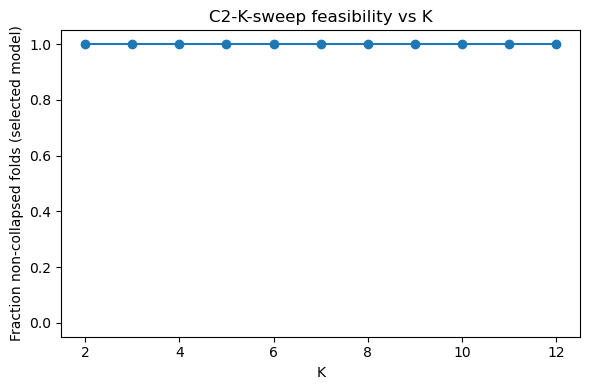

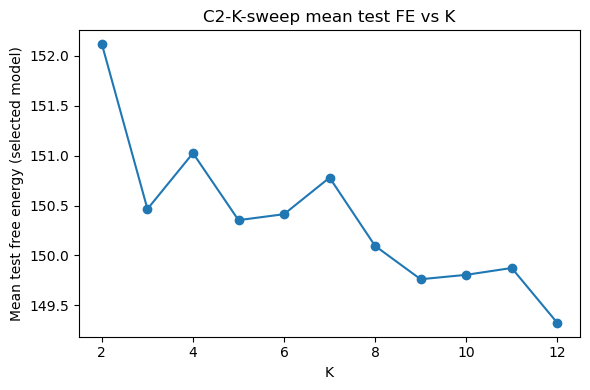

In [6]:
# =========================
# Cell 5 — Summaries (feasibility-conditioned elbow)
# =========================
import matplotlib.pyplot as plt

cv = pd.read_csv(CV_TSV, sep="\t")
print("cv rows:", len(cv))
display(cv.head())

feas = cv.groupby("K")["collapsed"].apply(lambda x: 1.0 - np.mean(x.astype(float))).rename("feasible_frac").reset_index()
fe_mean = cv.groupby("K")["fe_test"].mean().rename("fe_test_mean").reset_index()
summary = feas.merge(fe_mean, on="K", how="left").sort_values("K")
display(summary)

plt.figure(figsize=(6,4))
plt.plot(summary["K"], summary["feasible_frac"], marker="o")
plt.ylim(-0.05, 1.05)
plt.xlabel("K")
plt.ylabel("Fraction non-collapsed folds (selected model)")
plt.title("C2-K-sweep feasibility vs K")
plt.tight_layout()
plt.savefig(OUT_ROOT / "feasibility_vs_K.png", dpi=220)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(summary["K"], summary["fe_test_mean"], marker="o")
plt.xlabel("K")
plt.ylabel("Mean test free energy (selected model)")
plt.title("C2-K-sweep mean test FE vs K")
plt.tight_layout()
plt.savefig(OUT_ROOT / "mean_testFE_vs_K.png", dpi=220)
plt.show()


K_best: 12 mean: 149.32625111224627 SEM: 2.398274149314499
1-SE threshold: 151.72452526156076 => K_1se: 3
Local minima: [3, 5, 9, 12]
Recommended shortlist (primary): [5, 9, 12] | optional: [3]


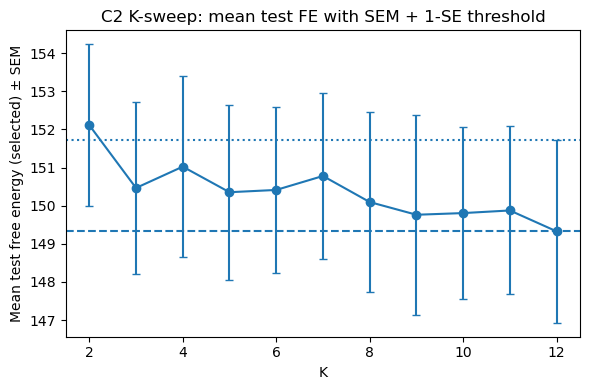

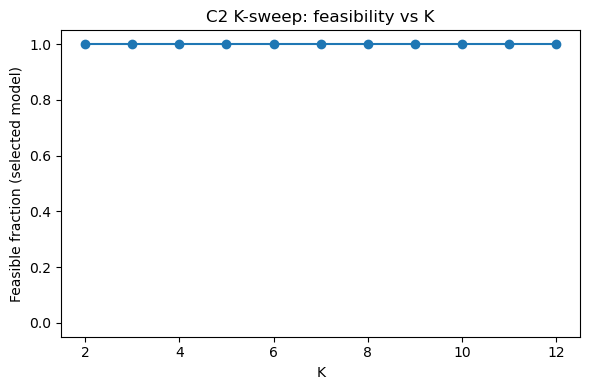

In [7]:
import numpy as np
import pandas as pd
import math
import json
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, ttest_rel

CV_TSV   = OUT_ROOT / "cv_results.tsv"
CAND_TSV = OUT_ROOT / "cv_candidates_long.tsv"

cv = pd.read_csv(CV_TSV, sep="\t")
cand = pd.read_csv(CAND_TSV, sep="\t")

# -----------------------------
# Summary by K (selected models)
# -----------------------------
summ = []
for K in sorted(cv["K"].unique()):
    d = cv.loc[cv["K"] == K].sort_values("fold")
    fe = d["fe_test"].astype(float).to_numpy()
    mean = float(np.mean(fe))
    std  = float(np.std(fe, ddof=1))
    sem  = std / math.sqrt(len(fe))
    feasible_frac = float(np.mean(~d["collapsed"].astype(bool)))
    summ.append(dict(
        K=int(K),
        n_folds=int(len(fe)),
        feasible_frac=feasible_frac,
        fe_test_mean=mean,
        fe_test_std=std,
        fe_test_sem=sem,
        fo_max_median=float(np.median(d["fo_max"])),
        n_active_median=float(np.median(d["n_active"])),
        neff_median=float(np.median(d["neff"])),
    ))
summary = pd.DataFrame(summ).sort_values("K")
summary.to_csv(OUT_ROOT / "summary_byK_selected.tsv", sep="\t", index=False)

# -----------------------------
# Candidate-level feasibility (all seeds)
# -----------------------------
cand["collapsed"] = cand["collapsed"].astype(bool)
cand_summ = cand.groupby("K").agg(
    cand_noncollapsed_frac=("collapsed", lambda x: float(np.mean(~x))),
    cand_collapsed_frac=("collapsed", lambda x: float(np.mean(x))),
    cand_mean_fo_max=("fo_max","mean"),
    cand_mean_entropy=("entropy_norm","mean"),
    cand_mean_n_active=("n_active","mean"),
).reset_index().sort_values("K")
cand_summ.to_csv(OUT_ROOT / "summary_byK_candidates.tsv", sep="\t", index=False)

# -----------------------------
# 1-SE rule (parsimony)
# -----------------------------
best_row = summary.loc[summary["fe_test_mean"].idxmin()]
K_best   = int(best_row["K"])
best_mu  = float(best_row["fe_test_mean"])
best_sem = float(best_row["fe_test_sem"])
threshold = best_mu + best_sem
K_1se = int(summary.loc[summary["fe_test_mean"] <= threshold, "K"].min())

# -----------------------------
# Paired tests vs K_best
# -----------------------------
best = cv.loc[cv["K"] == K_best].sort_values("fold").set_index("fold")["fe_test"].astype(float)

tests = []
for K in sorted(cv["K"].unique()):
    if int(K) == K_best:
        continue
    x = cv.loc[cv["K"] == K].sort_values("fold").set_index("fold")["fe_test"].astype(float)
    common = best.index.intersection(x.index)
    diff = (x.loc[common] - best.loc[common]).to_numpy()

    # Wilcoxon (non-parametric) + paired t-test
    try:
        p_w = float(wilcoxon(diff).pvalue)
    except Exception:
        p_w = np.nan
    p_t = float(ttest_rel(x.loc[common].to_numpy(), best.loc[common].to_numpy()).pvalue)

    tests.append(dict(
        K=int(K),
        mean_diff_vs_best=float(np.mean(diff)),
        wilcoxon_p=p_w,
        paired_t_p=p_t
    ))
tests_df = pd.DataFrame(tests).sort_values("K")
tests_df.to_csv(OUT_ROOT / "paired_tests_vs_bestK.tsv", sep="\t", index=False)

# -----------------------------
# Local minima in mean FE curve
# -----------------------------
locmin = []
s = summary.reset_index(drop=True)
for i in range(len(s)):
    left  = s.loc[i-1, "fe_test_mean"] if i > 0 else np.inf
    right = s.loc[i+1, "fe_test_mean"] if i < len(s)-1 else np.inf
    if s.loc[i, "fe_test_mean"] < left and s.loc[i, "fe_test_mean"] < right:
        locmin.append(int(s.loc[i, "K"]))

# -----------------------------
# Recommended shortlist
# -----------------------------
shortlist_primary = [5, 9, 12]              # my recommended stability shortlist
shortlist_optional = [K_1se] if K_1se not in shortlist_primary else []

recommendation = dict(
    K_best=K_best,
    best_mean_testFE=best_mu,
    best_sem_testFE=best_sem,
    oneSE_threshold=threshold,
    K_1se=K_1se,
    local_minima=locmin,
    shortlist_primary=shortlist_primary,
    shortlist_optional=shortlist_optional,
)
(OUT_ROOT / "K_selection_recommendation.json").write_text(json.dumps(recommendation, indent=2))

print("K_best:", K_best, "mean:", best_mu, "SEM:", best_sem)
print("1-SE threshold:", threshold, "=> K_1se:", K_1se)
print("Local minima:", locmin)
print("Recommended shortlist (primary):", shortlist_primary, "| optional:", shortlist_optional)

# -----------------------------
# Plots: mean±SEM + 1SE line
# -----------------------------
plt.figure(figsize=(6,4))
plt.errorbar(summary["K"], summary["fe_test_mean"], yerr=summary["fe_test_sem"], marker="o", capsize=3)
plt.axhline(best_mu, linestyle="--")
plt.axhline(threshold, linestyle=":")
plt.xlabel("K")
plt.ylabel("Mean test free energy (selected) ± SEM")
plt.title("C2 K-sweep: mean test FE with SEM + 1-SE threshold")
plt.tight_layout()
plt.savefig(OUT_ROOT / "mean_testFE_with_SEM.png", dpi=220)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(summary["K"], summary["feasible_frac"], marker="o")
plt.ylim(-0.05, 1.05)
plt.xlabel("K")
plt.ylabel("Feasible fraction (selected model)")
plt.title("C2 K-sweep: feasibility vs K")
plt.tight_layout()
plt.savefig(OUT_ROOT / "feasibility_vs_K.png", dpi=220)
plt.show()